# Oefening beschrijvende statistiek – 3DMiB-minorgroep (1)

**A)** Bereken de centrummaten (gemiddelde, mediaan, modus) voor de enquêtedata van de minorgroep.
**B)** Wat is bij numerieke data de betere maat: het gemiddelde of de mediaan?

Bron: Brightspace, FMSR Class 4 – `minor_survey.xlsx`. Zet het Excelbestand in dezelfde map als dit notebook.

## 1. Data inlezen
**Wat en waarom:** we lezen het Excelbestand in en bekijken de eerste rijen, zodat we weten welke variabelen er zijn voordat we iets uitrekenen.

In [1]:
import pandas as pd

df = pd.read_excel("minor_survey.xlsx")
print(df.shape)
df.head()

(24, 6)


,survey_id,han_student,programming_language,statistics_proficiency,expected_grade,length
0,1,no,python,2.0,9.0,160
1,2,yes,python,2.0,7.5,164
2,3,yes,python,NaN,5.5,186
3,4,yes,python,1.0,5.5,185
4,5,no,python,2.0,6.5,177


**Interpretatie:** de dataset heeft 24 respondenten (rijen) en 6 kolommen. `survey_id` is alleen een volgnummer en is geen echte variabele, dus die nemen we niet mee in de analyse.

## 2. Meetniveau per variabele bepalen
**Wat en waarom:** welke centrummaat je mag gebruiken, hangt af van het meetniveau. We controleren daarom eerst de datatypes en het aantal ontbrekende waarden.

| Variabele | Meetniveau | Toegestane centrummaten |
|---|---|---|
| `han_student` (yes/no) | Nominaal | Modus |
| `programming_language` | Nominaal | Modus |
| `statistics_proficiency` (schaal 1–5) | Ordinaal | Modus, mediaan |
| `expected_grade` | Interval/ratio | Modus, mediaan, gemiddelde |
| `length` (lengte in cm) | Ratio | Modus, mediaan, gemiddelde |

In [2]:
df.info()
print("\nOntbrekende waarden per kolom:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   survey_id               24 non-null     int64  
 1   han_student             24 non-null     str    
 2   programming_language    24 non-null     str    
 3   statistics_proficiency  23 non-null     float64
 4   expected_grade          24 non-null     float64
 5   length                  24 non-null     int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 1.3 KB

Ontbrekende waarden per kolom:
survey_id                 0
han_student               0
programming_language      0
statistics_proficiency    1
expected_grade            0
length                    0
dtype: int64


**Interpretatie:** `statistics_proficiency` heeft 1 ontbrekende waarde. Daardoor zijn de berekeningen voor die variabele gebaseerd op 23 in plaats van 24 respondenten. Pandas slaat lege cellen automatisch over (`skipna=True`), dus we hoeven niets te verwijderen. In het verslag moeten we dit wel vermelden.

## 3A. Centrummaten – categorische variabelen (nominaal)
**Wat en waarom:** bij nominale data kun je niet rekenen, dus we bekijken alleen de frequenties en de modus.

In [3]:
for col in ["han_student", "programming_language"]:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("Modus:", list(df[col].mode()), "\n")

--- han_student ---
han_student
yes    20
no      4
Name: count, dtype: int64
Modus: ['yes'] 

--- programming_language ---
programming_language
python    23
r          1
Name: count, dtype: int64
Modus: ['python'] 



**Interpretatie:** de modus van `han_student` is *yes*: 20 van de 24 respondenten studeren aan de HAN en 4 komen van buiten. De modus van `programming_language` is *python*: 23 van de 24 gebruiken Python, maar 1 persoon gebruikt R. Voor de docent betekent dit dat lesmateriaal in Python voor bijna de hele groep aansluit.

## 3B. Centrummaten – ordinale variabele
**Wat en waarom:** `statistics_proficiency` is een schaal van 1 tot 5. De volgorde heeft betekenis, maar de afstanden tussen de scores zijn niet per se gelijk. Daarom zijn de modus en de mediaan de juiste maten. Het gemiddelde rekenen we ter vergelijking ook uit, omdat het in de praktijk vaak gerapporteerd wordt.

In [4]:
sp = df["statistics_proficiency"]
print(sp.value_counts().sort_index())
print("\nModus:   ", list(sp.mode()))
print("Mediaan: ", sp.median())
print("Gemiddelde (ter info):", round(sp.mean(), 2))

statistics_proficiency
1.0     6
2.0    10
3.0     4
4.0     2
5.0     1
Name: count, dtype: int64

Modus:    [2.0]
Mediaan:  2.0
Gemiddelde (ter info): 2.22


**Interpretatie:** de meeste studenten beoordelen hun eigen statistiekkennis met een 2 (modus = 2, mediaan = 2). Het gemiddelde ligt iets hoger (≈ 2,22), omdat een paar studenten zichzelf een 4 of 5 geven. De groep schat zijn statistiekniveau dus vooral laag in. Voor de lessen betekent dit dat het verstandig is om bij de basis te beginnen.

## 3C. Centrummaten – numerieke variabelen
**Wat en waarom:** voor `expected_grade` en `length` mogen alle drie de centrummaten. We zetten ze in één tabel en voegen de scheefheid (*skewness*) toe. Daarmee beantwoorden we straks vraag B.

In [5]:
num_cols = ["statistics_proficiency", "expected_grade", "length"]

summary = pd.DataFrame({
    "n":          df[num_cols].count(),
    "gemiddelde": df[num_cols].mean().round(2),
    "mediaan":    df[num_cols].median(),
    "modus":      [", ".join(str(m) for m in df[c].mode()) for c in num_cols],
    "min":        df[num_cols].min(),
    "max":        df[num_cols].max(),
    "scheefheid": df[num_cols].skew().round(2),
})
summary

,n,gemiddelde,mediaan,modus,min,max,scheefheid
statistics_proficiency,23,2.22,2.0,2.0,1.0,5.0,0.93
expected_grade,24,7.31,7.0,"7.0, 8.0",5.5,9.2,0.06
length,24,177.79,180.0,180,160.0,191.0,-0.59


**Interpretatie:**
- **expected_grade:** het gemiddelde (7,31) en de mediaan (7,0) liggen dicht bij elkaar en de scheefheid is bijna 0 (0,06). De verdeling is dus vrijwel symmetrisch. Er zijn twee modi, 7,0 en 8,0, die allebei 6 keer voorkomen.
- **length:** de mediaan (180 cm) ligt hoger dan het gemiddelde (177,8 cm). De scheefheid is −0,59, dus de verdeling is licht linksscheef: een paar relatief kleine personen (160–167 cm) trekken het gemiddelde omlaag. De modus is 180 cm.
- **statistics_proficiency:** scheefheid +0,93, dus rechtsscheef door enkele hoge scores (4 en 5).

## 4. Visuele controle met histogrammen
**Wat en waarom:** met histogrammen zie je de vorm van de verdeling. We tekenen het gemiddelde en de mediaan als lijnen in, zodat je ziet waar ze uit elkaar lopen.

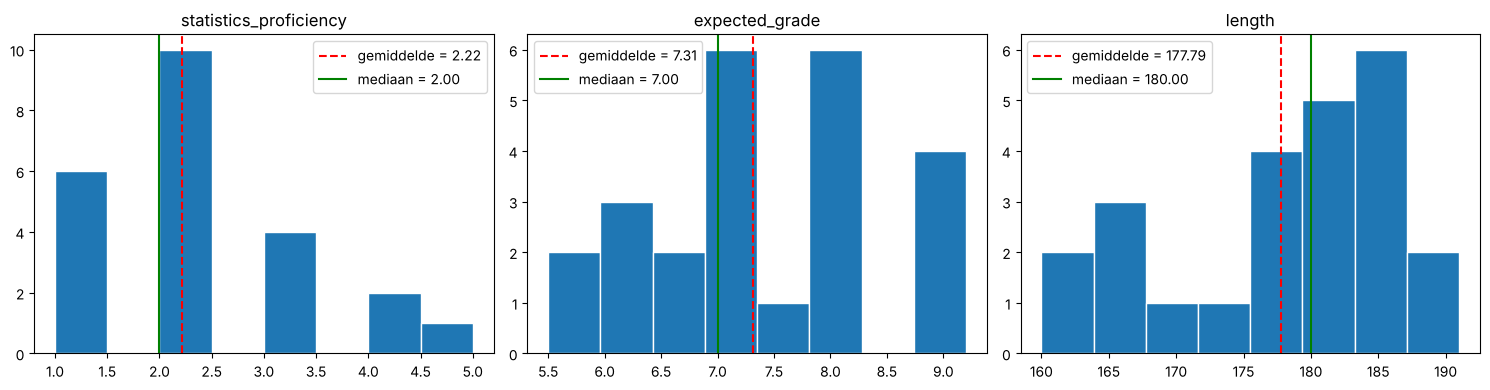

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=8, edgecolor="white")
    ax.axvline(data.mean(),   color="red",   linestyle="--", label=f"gemiddelde = {data.mean():.2f}")
    ax.axvline(data.median(), color="green", linestyle="-",  label=f"mediaan = {data.median():.2f}")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

**Interpretatie:** bij `expected_grade` vallen de lijnen van het gemiddelde en de mediaan bijna samen. Bij `length` ligt het gemiddelde links van de mediaan, en bij `statistics_proficiency` rechts ervan. Dat bevestigt de scheefheidswaarden uit de tabel.

## 5. Vraag B: gemiddelde of mediaan?

**Algemeen:** het gemiddelde gebruikt alle waarden en is daarom de beste maat bij een **symmetrische** verdeling zonder uitschieters. De mediaan is **robuust**: uitschieters en scheefheid hebben er geen invloed op. Daarom is de mediaan beter bij scheve data of data met extreme waarden. Vuistregel: ligt het gemiddelde duidelijk naast de mediaan, of is |scheefheid| groter dan ongeveer 0,5, kies dan de mediaan.

**Toegepast op deze data:**
- `expected_grade`: symmetrisch (scheefheid 0,06), dus het **gemiddelde** (7,31) is hier prima te gebruiken.
- `length`: licht scheef (−0,59) door een paar kleine waarden, dus de **mediaan** (180 cm) geeft een eerlijker beeld van de typische student.
- `statistics_proficiency`: ordinaal en bovendien scheef, dus de **mediaan** (2).

**Kanttekening:** met n = 24 is de groep klein. Eén extreme waarde heeft dan al veel invloed op het gemiddelde. Ook daarom is het verstandig om altijd beide maten te bekijken.